# Mô phỏng Mạng MLP & Thuật toán Lan truyền ngược (Backpropagation) từ đầu

Notebook này được xây dựng để giúp bạn hiểu rõ từng bước tính toán cơ bản của một mạng nơ-ron truyền thẳng nhiều lớp (Multi-Layer Perceptron - MLP) từ **Lan truyền tiến (Forward Propagation)** đến **Lan truyền ngược (Backpropagation)** sử dụng thư viện **NumPy**.

---
## PHẦN 1: MÔ PHỎNG LAN TRUYỀN TIẾN (FORWARD PROPAGATION)

Theo sơ đồ slide của bạn, mạng của chúng ta có cấu trúc 4 lớp:
- **Lớp đầu vào ($a^0$):** 3 node ($n_0 = 3$)
- **Lớp ẩn 1 ($a^1$):** 4 node ($n_1 = 4$)
- **Lớp ẩn 2 ($a^2$):** 4 node ($n_2 = 4$)
- **Lớp đầu ra ($a^3$ hay $a^L = \hat{y}$):** 2 node ($n_3 = 2$)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cố định random seed để kết quả in ra không đổi mỗi lần chạy
np.random.seed(42)

# Định nghĩa hàm kích hoạt g(z) và đạo hàm của chúng
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):
    # Đạo hàm tính theo giá trị kích hoạt a = sigmoid(z)
    return a * (1 - a)

# Khởi tạo kích thước các lớp (3 -> 4 -> 4 -> 2)
n_x = 3   # Số node lớp input
n_h1 = 4  # Số node lớp ẩn 1
n_h2 = 4  # Số node lớp ẩn 2
n_y = 2   # Số node lớp output

# Khởi tạo trọng số W và bias b
# W có kích thước (n_sau, n_truoc), b có kích thước (n_sau, 1)
W1 = np.random.randn(n_h1, n_x) * 0.1
b1 = np.zeros((n_h1, 1))

W2 = np.random.randn(n_h2, n_h1) * 0.1
b2 = np.zeros((n_h2, 1))

W3 = np.random.randn(n_y, n_h2) * 0.1
b3 = np.zeros((n_y, 1))

print("Đã khởi tạo xong thư viện và các tham số W, b!")

### Lớp đầu vào ($a^0 = x$)

In [ ]:
# a^0 = x: đầu vào của mạng
x = np.random.randn(n_x, 1) 
a0 = x

print("--- BƯỚC 1: ĐẦU VÀO ---")
print(f"a0 (Kích thước {a0.shape}):\n{a0}")

--- BƯỚC 1: ĐẦU VÀO ---
a0 (Kích thước (3, 1)):
[[ 0.2088636 ]
 [-1.95967012]
 [-1.32818605]]


### Lớp ẩn 1 ($l=1$)
Công thức:
$$z^1 = W^1 a^0 + b^1$$
$$a^1 = \text{ReLU}(z^1)$$

In [ ]:
# z^1 = W^1 * a^0 + b^1
z1 = np.dot(W1, a0) + b1

# a^1 = g^1(z1) (Dùng ReLU)
a1 = relu(z1)

print("--- BƯỚC 2: LỚP ẨN 1 ---")
print(f"z1 (Kích thước {z1.shape}):\n{z1}\n")
print(f"a1 (ReLU, kích thước {a1.shape}):\n{a1}")

--- BƯỚC 2: LỚP ẨN 1 ---
z1 (Kích thước (4, 1)):
[[-0.0485553 ]
 [ 0.10879463]
 [-0.05505295]
 [ 0.16400426]]

a1 (ReLU, kích thước (4, 1)):
[[0.        ]
 [0.10879463]
 [0.        ]
 [0.16400426]]


### Lớp ẩn 2 ($l=2$)
Công thức:
$$z^2 = W^2 a^1 + b^2$$
$$a^2 = \text{ReLU}(z^2)$$

In [ ]:
# z^2 = W^2 * a^1 + b^2
z2 = np.dot(W2, a1) + b2

# a^2 = g^2(z^2) (Dùng ReLU)
a2 = relu(z2)

print("--- BƯỚC 3: LỚP ẨN 2 ---")
print(f"z2 (Kích thước {z2.shape}):\n{z2}\n")
print(f"a2 (ReLU, kích thước {a2.shape}):\n{a2}")

--- BƯỚC 3: LỚP ẨN 2 ---
z2 (Kích thước (4, 1)):
[[-0.03003722]
 [-0.01974354]
 [-0.0258228 ]
 [ 0.00736839]]

a2 (ReLU, kích thước (4, 1)):
[[0.        ]
 [0.        ]
 [0.        ]
 [0.00736839]]


### Lớp đầu ra ($l=3$ hay $L$)
Công thức:
$$z^3 = W^3 a^2 + b^3$$
$$a^3 = \hat{y} = \text{Sigmoid}(z^3)$$

In [ ]:
# z^3 = W^3 * a^2 + b^3
z3 = np.dot(W3, a2) + b3

# a^3 = g^3(z3) (Dùng Sigmoid cho đầu ra)
a3 = sigmoid(z3)
y_hat = a3

print("--- BƯỚC 4: LỚP ĐẦU RA (DỰ ĐOÁN) ---")
print(f"z3 (Kích thước {z3.shape}):\n{z3}\n")
print(f"y_hat (Sigmoid, kích thước {y_hat.shape}):\n{y_hat}")

--- BƯỚC 4: LỚP ĐẦU RA (DỰ ĐOÁN) ---
z3 (Kích thước (2, 1)):
[[ 0.00136483]
 [-0.00089956]]

y_hat (Sigmoid, kích thước (2, 1)):
[[0.50034121]
 [0.49977511]]


---
## PHẦN 2: MÔ PHỎNG LAN TRUYỀN NGƯỢC (BACKPROPAGATION)

Bây giờ, chúng ta sẽ định nghĩa một nhãn thực tế $y$ (target) và thực hiện **1 bước lan truyền ngược** để tính toán các sai số $\delta$ và gradient của tham số.

Giả sử nhãn mục tiêu cho mẫu hiện tại là:
$$y = \begin{bmatrix} 0.5 \\ 0.1 \end{bmatrix}$$
Hàm lỗi MSE:
$$L = \frac{1}{2} \sum_{i} (y_i - y\_hat_i)^2$$

In [ ]:
# Khởi tạo nhãn thực tế y
y = np.array([[0.5], [0.1]])

print("--- BƯỚC 5: TÍNH SAI SỐ VÀ LAN TRUYỀN NGƯỢC ---")

# 1. Sai số tại lớp đầu ra L = 3 (delta3)
# delta3 = (a3 - y) * g3'(z3)
# Vì g3 là Sigmoid, g3'(z3) = a3 * (1 - a3)
delta3 = (a3 - y) * sigmoid_derivative(a3)
print(f"delta3 (lớp đầu ra, kích thước {delta3.shape}):\n{delta3}\n")

# 2. Lan truyền sai số về lớp ẩn 2 (delta2)
# delta2 = (W3^T * delta3) * g2'(z2)
# Vì g2 là ReLU, g2'(z2) = 1 nếu z2 > 0, ngược lại bằng 0
delta2 = np.dot(W3.T, delta3) * relu_derivative(z2)
print(f"delta2 (lớp ẩn 2, kích thước {delta2.shape}):\n{delta2}\n")

# 3. Lan truyền sai số về lớp ẩn 1 (delta1)
# delta1 = (W2^T * delta2) * g1'(z1)
delta1 = np.dot(W2.T, delta2) * relu_derivative(z1)
print(f"delta1 (lớp ẩn 1, kích thước {delta1.shape}):\n{delta1}\n")

--- BƯỚC 5: TÍNH SAI SỐ VÀ LAN TRUYỀN NGƯỢC ---
delta3 (lớp đầu ra, kích thước (2, 1)):
[[8.53018237e-05]
 [9.99437570e-02]]

delta2 (lớp ẩn 2, kích thước (4, 1)):
[[-0.        ]
 [-0.        ]
 [ 0.        ]
 [-0.01218577]]

delta1 (lớp ẩn 1, kích thước (4, 1)):
[[ 0.        ]
 [-0.00013517]
 [ 0.        ]
 [-0.00045782]]



### Tính toán Gradient cho các tham số và cập nhật

In [ ]:
# 4. Tính toán Gradients
dW3 = np.dot(delta3, a2.T)
db3 = delta3

dW2 = np.dot(delta2, a1.T)
db2 = delta2

dW1 = np.dot(delta1, a0.T)
db1 = delta1

print("--- GRADIENTS CỦA TRỌNG SỐ W (Độ dốc) ---")
print(f"dW3 (Kích thước {dW3.shape}):\n{dW3}\n")
print(f"dW2 (Kích thước {dW2.shape}):\n{dW2}\n")
print(f"dW1 (Kích thước {dW1.shape}):\n{dW1}\n")

# 5. Thử cập nhật trọng số với tốc độ học lr = 0.1
lr = 0.1
W3_new = W3 - lr * dW3
W2_new = W2 - lr * dW2
W1_new = W1 - lr * dW1

print("--- CẬP NHẬT TRỌNG SỐ ---")
print("Trọng số W3 trước khi cập nhật:\n", W3)
print("Trọng số W3 sau khi cập nhật:\n", W3_new)

--- GRADIENTS CỦA TRỌNG SỐ W (Độ dốc) ---
dW3 (Kích thước (2, 4)):
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 6.28536747e-07]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 7.36424160e-04]]

dW2 (Kích thước (4, 4)):
[[ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.         -0.00132575  0.         -0.00199852]]

dW1 (Kích thước (4, 3)):
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.82316148e-05  2.64884132e-04  1.79527873e-04]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-9.56212957e-05  8.97170215e-04  6.08066097e-04]]

--- CẬP NHẬT TRỌNG SỐ ---
Trọng số W3 trước khi cập nhật:
 [[-0.06006387 -0.02916937 -0.06017066  0.18522782]
 [-0.00134972 -0.10577109  0.08225449 -0.12208436]]
Trọng số W3 sau khi cập nhật:
 [[-0.06006387 -0.02916937 -0.06017066  0.18522776]
 [-0.00134972 -0.10577109  0.08225449 -0.12215801]]


---
## PHẦN 3: LỚP PHÂN LOẠI MLP HOÀN CHỈNH (MLP CLASSIFIER CLASS)

Dưới đây là cài đặt một class MLPClassifier hoàn chỉnh hỗ trợ đào tạo mô hình trên các tập dữ liệu bằng giải thuật **Batch Gradient Descent**.

In [ ]:
class MLPClassifier:
    def __init__(self, layer_sizes, learning_rate=0.1, epochs=1000):
        self.layer_sizes = layer_sizes
        self.lr = learning_rate
        self.epochs = epochs
        
        # Khởi tạo trọng số W và bias b
        self.W = []
        self.b = []
        
        for i in range(1, len(layer_sizes)):
            # Sử dụng khởi tạo He
            limit = np.sqrt(2.0 / layer_sizes[i - 1])
            self.W.append(np.random.randn(layer_sizes[i], layer_sizes[i - 1]) * limit)
            self.b.append(np.zeros((layer_sizes[i], 1)))
            
        self.loss_history = []
        self.accuracy_history = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    @staticmethod
    def _sigmoid_derivative(a):
        return a * (1.0 - a)

    def _forward(self, X):
        a_values = [X]
        z_values = []
        
        a = X
        for W_l, b_l in zip(self.W, self.b):
            z = np.dot(W_l, a) + b_l
            a = self._sigmoid(z)
            z_values.append(z)
            a_values.append(a)
            
        return a_values, z_values

    def _backward(self, a_values, y):
        n_samples = y.shape[1]
        dW = []
        db = []
        
        a_out = a_values[-1]
        delta = (a_out - y) * self._sigmoid_derivative(a_out)
        
        num_layers = len(self.W)
        for l in reversed(range(num_layers)):
            a_prev = a_values[l]
            
            dW_l = (1.0 / n_samples) * np.dot(delta, a_prev.T)
            db_l = (1.0 / n_samples) * np.sum(delta, axis=1, keepdims=True)
            
            dW.insert(0, dW_l)
            db.insert(0, db_l)
            
            if l > 0:
                delta = np.dot(self.W[l].T, delta) * self._sigmoid_derivative(a_prev)
                
        return dW, db

    def fit(self, X, y):
        # Chuyển đổi định dạng dữ liệu (n_features, n_samples)
        X_input = X.T
        if len(y.shape) == 1:
            y_input = y.reshape(1, -1)
        else:
            y_input = y.T
            
        self.loss_history = []
        self.accuracy_history = []
        
        for epoch in range(self.epochs):
            a_values, _ = self._forward(X_input)
            y_hat = a_values[-1]
            
            loss = 0.5 * np.mean(np.sum((y_hat - y_input) ** 2, axis=0))
            self.loss_history.append(loss)
            
            preds = (y_hat >= 0.5).astype(int)
            acc = float(np.mean(preds == y_input))
            self.accuracy_history.append(acc)
            
            dW, db = self._backward(a_values, y_input)
            
            for l in range(len(self.W)):
                self.W[l] -= self.lr * dW[l]
                self.b[l] -= self.lr * db[l]
                
            if (epoch + 1) % (self.epochs // 10 or 1) == 0 or epoch == 0:
                print(f"Epoch {epoch+1:4d}/{self.epochs} - Loss: {loss:.6f} - Acc: {acc:.2%}")
                
        return self

    def predict_proba(self, X):
        X_input = X.T
        a_values, _ = self._forward(X_input)
        return a_values[-1].T

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        if probs.shape[1] == 1:
            return (probs >= threshold).astype(int).ravel()
        return (probs >= threshold).astype(int)

### Kiểm thử với bài toán XOR nổi tiếng

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

mlp = MLPClassifier(layer_sizes=[2, 4, 1], learning_rate=0.5, epochs=3000)
mlp.fit(X, y)

print("\nKết quả dự đoán:")
probs = mlp.predict_proba(X).ravel()
preds = mlp.predict(X)
for i in range(len(X)):
    print(f"Input: {X[i]} | Target: {y[i]} | Probability: {probs[i]:.4f} | Prediction: {preds[i]}")

Epoch    1/3000 - Loss: 0.127475 - Acc: 75.00%
Epoch  300/3000 - Loss: 0.120342 - Acc: 50.00%
Epoch  600/3000 - Loss: 0.113042 - Acc: 75.00%
Epoch  900/3000 - Loss: 0.102852 - Acc: 75.00%
Epoch 1200/3000 - Loss: 0.091486 - Acc: 75.00%
Epoch 1500/3000 - Loss: 0.077895 - Acc: 75.00%
Epoch 1800/3000 - Loss: 0.059094 - Acc: 100.00%
Epoch 2100/3000 - Loss: 0.038516 - Acc: 100.00%
Epoch 2400/3000 - Loss: 0.023679 - Acc: 100.00%
Epoch 2700/3000 - Loss: 0.015253 - Acc: 100.00%
Epoch 3000/3000 - Loss: 0.010581 - Acc: 100.00%

Kết quả dự đoán:
Input: [0 0] | Target: 0 | Probability: 0.1191 | Prediction: 0
Input: [0 1] | Target: 1 | Probability: 0.8536 | Prediction: 1
Input: [1 0] | Target: 1 | Probability: 0.8647 | Prediction: 1
Input: [1 1] | Target: 0 | Probability: 0.1749 | Prediction: 0


### Trực quan hóa Ranh giới quyết định (Decision Boundary) trên tập dữ liệu Moons

Epoch    1/2000 - Loss: 0.140099 - Acc: 49.38%
Epoch  200/2000 - Loss: 0.110148 - Acc: 81.25%
Epoch  400/2000 - Loss: 0.095204 - Acc: 83.12%
Epoch  600/2000 - Loss: 0.079104 - Acc: 84.38%
Epoch  800/2000 - Loss: 0.067101 - Acc: 84.38%
Epoch 1000/2000 - Loss: 0.059692 - Acc: 84.69%
Epoch 1200/2000 - Loss: 0.055254 - Acc: 85.31%
Epoch 1400/2000 - Loss: 0.052532 - Acc: 86.25%
Epoch 1600/2000 - Loss: 0.050815 - Acc: 86.25%
Epoch 1800/2000 - Loss: 0.049704 - Acc: 86.88%
Epoch 2000/2000 - Loss: 0.048965 - Acc: 86.88%

Test Accuracy: 80.00%


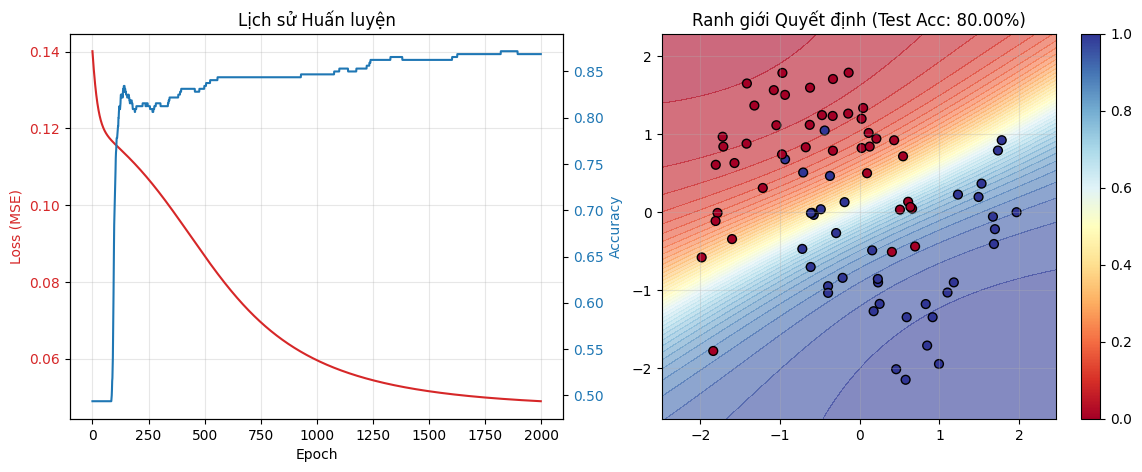

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Sinh dữ liệu mẫu
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Huấn luyện MLP Classifier
mlp_moon = MLPClassifier(layer_sizes=[2, 8, 4, 1], learning_rate=0.2, epochs=2000)
mlp_moon.fit(X_train, y_train)

test_preds = mlp_moon.predict(X_test)
test_acc = np.mean(test_preds == y_test)
print(f"\nTest Accuracy: {test_acc:.2%}")

# 3. Vẽ đồ thị kết quả
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị Loss & Accuracy
axes[0].plot(mlp_moon.loss_history, color='tab:red', label='Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)', color='tab:red')
axes[0].tick_params(axis='y', labelcolor='tab:red')

ax2 = axes[0].twinx()
ax2.plot(mlp_moon.accuracy_history, color='tab:blue', label='Accuracy')
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
axes[0].set_title("Lịch sử Huấn luyện")
axes[0].grid(True, alpha=0.3)

# Đồ thị Decision Boundary
x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = mlp_moon.predict_proba(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, probs, levels=50, cmap='RdYlBu', alpha=0.6)
scatter = axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', edgecolors='black', s=40)
axes[1].set_title(f"Ranh giới Quyết định (Test Acc: {test_acc:.2%})")
plt.colorbar(scatter, ax=axes[1])
axes[1].grid(True, alpha=0.3)

plt.show()